In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
  
from sklearn.preprocessing import PowerTransformer

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D3
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Yeo-Johnson Transformation for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_numeric_std = pt.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

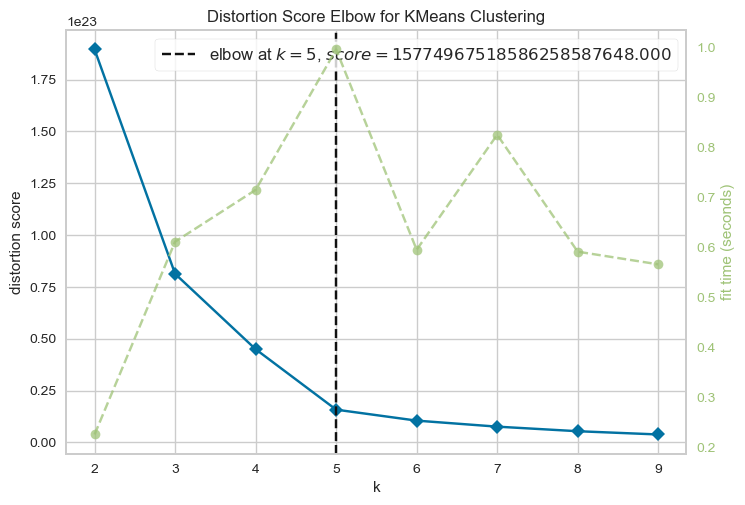

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# How many clusters to form - 1. Using elbow method 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: shape_Elongation
Correlation coefficient: 1.0072463768115953


1
Most correlated column: glcm_DifferenceAverage_d_1_PET_c04
Correlation coefficient: 1.0072463768115951


2
Most correlated column: glszm_GrayLevelNonUniformity_PET_c04
Correlation coefficient: 1.0072463768115951


3
Most correlated column: LBP_102_PET
Correlation coefficient: 1.0072463768115956


4
Most correlated column: first_order_RobustMeanAbsoluteDeviation_PET
Correlation coefficient: 1.0072463768115951




In [21]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Yeo-Johnson Transformation

In [22]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [23]:
X_new

,shape_Elongation,glcm_DifferenceAverage_d_1_PET_c04,glszm_GrayLevelNonUniformity_PET_c04,LBP_102_PET,first_order_RobustMeanAbsoluteDeviation_PET
0,0.600926,0.356587,1.545455,0.000000,2.608982
1,0.841579,0.420129,2.166667,0.000000,0.978390
2,0.772821,0.325835,6.777778,0.000034,1.184765
3,0.847727,0.401664,2.090909,0.000000,0.421149
4,0.831483,0.510112,4.333333,0.000199,0.914508
...,...,...,...,...,...
134,0.680294,0.409956,4.000000,0.000000,1.571160
135,0.758193,0.321183,4.000000,0.000000,0.941343
136,0.770113,0.374487,2.428571,0.000000,2.262096
137,0.628897,0.402135,6.333333,0.000000,1.167062


In [24]:
X_new_std

,shape_Elongation,glcm_DifferenceAverage_d_1_PET_c04,glszm_GrayLevelNonUniformity_PET_c04,LBP_102_PET,first_order_RobustMeanAbsoluteDeviation_PET
0,-0.735252,-0.094031,-1.814187,-0.784694,0.929474
1,1.029207,0.595643,-1.216065,-0.784694,-0.726455
2,0.480839,-0.468257,0.613776,0.236612,-0.444272
3,1.080021,0.405940,-1.278916,-0.784694,-1.693580
4,0.946400,1.412495,-0.046796,1.784568,-0.820591
...,...,...,...,...,...
134,-0.200607,0.492151,-0.174107,-0.784694,0.011153
135,0.368838,-0.527421,-0.174107,-0.784694,-0.780622
136,0.459982,0.111075,-1.015564,-0.784694,0.659936
137,-0.551976,0.410886,0.519526,-0.784694,-0.467274


In [25]:
MAASTRO_new

,shape_Elongation,glcm_DifferenceAverage_d_1_PET_c04,glszm_GrayLevelNonUniformity_PET_c04,LBP_102_PET,first_order_RobustMeanAbsoluteDeviation_PET
0,0.765178,0.335443,7.437500,0.000026,2.804536
1,0.776540,0.279434,6.111111,0.000167,1.112878
2,0.697164,0.310763,2.750000,0.000057,2.210455
3,0.574636,0.301684,3.000000,0.000000,1.225669
4,0.633419,0.300615,8.428571,0.000000,1.428017
...,...,...,...,...,...
94,0.882411,0.327473,3.842105,0.000000,7.089688
95,0.535802,0.310449,1.727273,0.000000,2.165934
96,0.716610,0.264803,9.666667,0.000000,1.052365
97,0.665145,0.305581,5.352941,0.000000,2.313589


In [26]:
MAASTRO_new_std

,shape_Elongation,glcm_DifferenceAverage_d_1_PET_c04,glszm_GrayLevelNonUniformity_PET_c04,LBP_102_PET,first_order_RobustMeanAbsoluteDeviation_PET
0,0.422117,-0.348239,0.739277,0.033184,1.068840
1,0.509566,-1.090997,0.469013,1.682719,-0.539020
2,-0.081096,-0.662484,-0.799685,0.693043,0.617054
3,-0.902489,-0.783134,-0.650645,-0.784694,-0.391916
4,-0.521824,-0.797524,0.901693,-0.784694,-0.147962
...,...,...,...,...,...
94,1.372275,-0.447593,-0.239100,-0.784694,2.961685
95,-1.140744,-0.666615,-1.617427,-0.784694,0.579456
96,0.059266,-1.303381,1.070911,-0.784694,-0.621639
97,-0.306155,-0.731004,0.276497,-0.784694,0.701938


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [27]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 14:02:55,527] A new study created in memory with name: no-name-b75bbc6a-a75b-4351-aa59-f8fda5278d15


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.627906976744186
Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.6806083650190115


[I 2024-04-17 14:02:56,838] A new study created in memory with name: no-name-76ef6d9d-9d50-49a3-9b83-3acc84c16794


Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:02:56,702] Trial 0 finished with value: 0.6628447858402818 and parameters: {}. Best is trial 0 with value: 0.6628447858402818.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6628447858402818], datetime_start=datetime.datetime(2024, 4, 17, 14, 2, 55, 872101), datetime_complete=datetime.datetime(2024, 4, 17, 14, 2, 56, 702179), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6628447858402818


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2956613198677841
Fold 2 IBS: 0.2218836843567758
Fold 3 IBS: 0.1654696909667572
Fold 4 IBS: 0.22839687405386314
Fold 5 IBS: 0.1996368799434783
[I 2024-04-17 14:02:58,650] Trial 0 finished with value: 0.2222096898377317 and parameters: {}. Best is trial 0 with value: 0.2222096898377317.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2222096898377317], datetime_start=datetime.datetime(2024, 4, 17, 14, 2, 57, 202632), datetime_complete=datetime.datetime(2024, 4, 17, 14, 2, 58, 650448), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2222096898377317


In [28]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [29]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.663
train_ibs:  0.222


#### Test

In [30]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [31]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.477
IBS score: 0.287


In [32]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [33]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [34]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 14:02:59,084] A new study created in memory with name: no-name-e9c3f176-7f0a-4c2a-94d5-642fecf35639


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.4760956175298805
Fold 2 C-index: 0.5678294573643411


[I 2024-04-17 14:02:59,868] A new study created in memory with name: no-name-12c77516-bbf7-4177-8a4e-fa168766c58d


Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.5042918454935622
[I 2024-04-17 14:02:59,854] Trial 0 finished with value: 0.5691693124005079 and parameters: {}. Best is trial 0 with value: 0.5691693124005079.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5691693124005079], datetime_start=datetime.datetime(2024, 4, 17, 14, 2, 59, 358257), datetime_complete=datetime.datetime(2024, 4, 17, 14, 2, 59, 854415), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5691693124005079


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724710115388523
Fold 2 IBS: 0.23203988106293078
Fold 3 IBS: 0.2289818635027129
Fold 4 IBS: 0.24197476260705048
Fold 5 IBS: 0.22939559338298313
[I 2024-04-17 14:03:00,539] Trial 0 finished with value: 0.2359278403419125 and parameters: {}. Best is trial 0 with value: 0.2359278403419125.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2359278403419125], datetime_start=datetime.datetime(2024, 4, 17, 14, 2, 59, 904941), datetime_complete=datetime.datetime(2024, 4, 17, 14, 3, 0, 539624), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2359278403419125


In [35]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [36]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.569
train_ibs:  0.236


#### Test

In [37]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [38]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.484


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [39]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [40]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 14:03:01,126] A new study created in memory with name: no-name-9e438e56-02be-4a09-b57d-a3014c10718d


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6317829457364341
Fold 3 C-index: 0.8127659574468085


[I 2024-04-17 14:03:02,722] A new study created in memory with name: no-name-ba71a927-debb-4b7c-be4b-49d552ae5e50


Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:02,702] Trial 0 finished with value: 0.6635293720827085 and parameters: {}. Best is trial 0 with value: 0.6635293720827085.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6635293720827085], datetime_start=datetime.datetime(2024, 4, 17, 14, 3, 1, 596007), datetime_complete=datetime.datetime(2024, 4, 17, 14, 3, 2, 698613), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6635293720827085


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.29316680181260996
Fold 2 IBS: 0.22120753871204984
Fold 3 IBS: 0.16646685719098323
Fold 4 IBS: 0.22772304783030978
Fold 5 IBS: 0.1999388791137786
[I 2024-04-17 14:03:03,577] Trial 0 finished with value: 0.22170062493194628 and parameters: {}. Best is trial 0 with value: 0.22170062493194628.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.22170062493194628], datetime_start=datetime.datetime(2024, 4, 17, 14, 3, 2, 763934), datetime_complete=datetime.datetime(2024, 4, 17, 14, 3, 3, 576538), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.22170062493194628


In [41]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [42]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.664
train_ibs:  0.222


#### Test

In [43]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [44]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.476


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.286


In [45]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [46]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 14:03:04,038] A new study created in memory with name: no-name-0a7d4663-49c0-421f-b744-130644401dd4


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6317829457364341
Fold 3 C-index: 0.8127659574468085
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:05,050] Trial 0 finished with value: 0.6635293720827085 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6635293720827085.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.627906976744186
Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:05,655] Trial 1 finished with value: 0.6228447858402818 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6635293720827085.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.627906976744186
Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:06,328] Trial 2 finished with value: 0.6228447858402818 and parameters: {'l1_ratio': 0.22692876841884668}. Best is

Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6317829457364341
Fold 3 C-index: 0.8127659574468085
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:21,365] Trial 24 finished with value: 0.6635293720827085 and parameters: {'l1_ratio': 0.7847506628873072}. Best is trial 3 with value: 0.6643804359124957.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6317829457364341
Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:22,171] Trial 25 finished with value: 0.6643804359124957 and parameters: {'l1_ratio': 0.5040550905771146}. Best is trial 3 with value: 0.6643804359124957.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.627906976744186
Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:23,058] Trial 26 finished with value: 0.6636052421140461 and parameters: {'l1_ratio': 0.3527001258697712}. Best 

Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6317829457364341
Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:38,595] Trial 48 finished with value: 0.6643804359124957 and parameters: {'l1_ratio': 0.6103289469725394}. Best is trial 3 with value: 0.6643804359124957.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6317829457364341
Fold 3 C-index: 0.8127659574468085
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:39,241] Trial 49 finished with value: 0.6635293720827085 and parameters: {'l1_ratio': 0.9391526082026955}. Best is trial 3 with value: 0.6643804359124957.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.627906976744186
Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6866952789699571
[I 2024-04-17 14:03:39,896] Trial 50 finished with value: 0.6636052421140461 and parameters: {'l1_ratio': 0.41653985858071785}. Best

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.29328840024159636
Fold 2 IBS: 0.22116195603099084
Fold 3 IBS: 0.16644820128874022
Fold 4 IBS: 0.22777272698968315
Fold 5 IBS: 0.1999432191559927
[I 2024-04-17 14:04:18,037] Trial 0 finished with value: 0.22172290074140064 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.22172290074140064.
Fold 1 IBS: 0.2932776012487174
Fold 2 IBS: 0.22111866112097053
Fold 3 IBS: 0.2227162022413331
Fold 4 IBS: 0.22793234621104155
Fold 5 IBS: 0.20003287299086694
[I 2024-04-17 14:04:18,984] Trial 1 finished with value: 0.2330155367625859 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.22172290074140064.
Fold 1 IBS: 0.29335173815839416
Fold 2 IBS: 0.22113367766783779
Fold 3 IBS: 0.22340282311036744
Fold 4 IBS: 0.22799732656529717
Fold 5 IBS: 0.2000333937186682
[I 2024-04-17 14:04:20,056] Trial 2 finished with value: 0.23318379184411295 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.22172290074140

Fold 1 IBS: 0.2932954440391807
Fold 2 IBS: 0.22117524455073584
Fold 3 IBS: 0.16648841793253688
Fold 4 IBS: 0.2277203209494328
Fold 5 IBS: 0.19992849581035918
[I 2024-04-17 14:04:43,234] Trial 25 finished with value: 0.22172158465644903 and parameters: {'l1_ratio': 0.891573855041803}. Best is trial 16 with value: 0.2216922352772365.
Fold 1 IBS: 0.29316687450703044
Fold 2 IBS: 0.22119648095784084
Fold 3 IBS: 0.16642506847905905
Fold 4 IBS: 0.2277165587786592
Fold 5 IBS: 0.19995345327432038
[I 2024-04-17 14:04:44,016] Trial 26 finished with value: 0.22169168719938198 and parameters: {'l1_ratio': 0.7737432894764847}. Best is trial 26 with value: 0.22169168719938198.
Fold 1 IBS: 0.29315036591701377
Fold 2 IBS: 0.22118125330634703
Fold 3 IBS: 0.16639051559632173
Fold 4 IBS: 0.22776863823876123
Fold 5 IBS: 0.19997004677835406
[I 2024-04-17 14:04:44,807] Trial 27 finished with value: 0.2216921639673596 and parameters: {'l1_ratio': 0.610614834481184}. Best is trial 26 with value: 0.221691687199

Fold 1 IBS: 0.293379966826942
Fold 2 IBS: 0.22114352020476627
Fold 3 IBS: 0.22334862153853863
Fold 4 IBS: 0.22799828537952482
Fold 5 IBS: 0.20002736381191735
[I 2024-04-17 14:05:08,503] Trial 50 finished with value: 0.23317955155233783 and parameters: {'l1_ratio': 0.2311229033161103}. Best is trial 31 with value: 0.22169014523194236.
Fold 1 IBS: 0.2931682496699737
Fold 2 IBS: 0.22119692272017213
Fold 3 IBS: 0.16642477313670762
Fold 4 IBS: 0.22771659868799327
Fold 5 IBS: 0.19995318587054212
[I 2024-04-17 14:05:09,359] Trial 51 finished with value: 0.22169194601707773 and parameters: {'l1_ratio': 0.7748409634903562}. Best is trial 31 with value: 0.22169014523194236.
Fold 1 IBS: 0.2932205125451744
Fold 2 IBS: 0.22121371045424873
Fold 3 IBS: 0.1664134184307454
Fold 4 IBS: 0.22771812073579598
Fold 5 IBS: 0.19994303221771617
[I 2024-04-17 14:05:10,249] Trial 52 finished with value: 0.22170175887673613 and parameters: {'l1_ratio': 0.8189550461365139}. Best is trial 31 with value: 0.2216901452

Fold 1 IBS: 0.29332660192785404
Fold 2 IBS: 0.2211753638950289
Fold 3 IBS: 0.16643920561517672
Fold 4 IBS: 0.22777387124832954
Fold 5 IBS: 0.1999662485223252
[I 2024-04-17 14:05:33,555] Trial 75 finished with value: 0.22173625824174287 and parameters: {'l1_ratio': 0.7246217951054079}. Best is trial 55 with value: 0.22168959139653413.
Fold 1 IBS: 0.2931848058204047
Fold 2 IBS: 0.221192305797106
Fold 3 IBS: 0.1663831047270315
Fold 4 IBS: 0.22776965166335345
Fold 5 IBS: 0.19996334182517514
[I 2024-04-17 14:05:34,711] Trial 76 finished with value: 0.22169864196661412 and parameters: {'l1_ratio': 0.6300326467603683}. Best is trial 55 with value: 0.22168959139653413.
Fold 1 IBS: 0.2932410970089763
Fold 2 IBS: 0.22122032179731282
Fold 3 IBS: 0.16640901061502786
Fold 4 IBS: 0.22771872304772825
Fold 5 IBS: 0.19993902862520882
[I 2024-04-17 14:05:35,585] Trial 77 finished with value: 0.2217056362188508 and parameters: {'l1_ratio': 0.8377165253292933}. Best is trial 55 with value: 0.2216895913965

In [47]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [48]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.664
train_ibs:  0.222


#### Test

In [49]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [50]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.5513596376059829)

test_cindex : 0.476


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.7649650880135609)

test_ibs:  0.286


In [51]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [52]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 14:05:54,275] A new study created in memory with name: no-name-4910f0ba-e6b4-4d67-bd43-b6bcf0c9f0b6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.630901287553648
[I 2024-04-17 14:06:03,033] Trial 0 finished with value: 0.6193402560664847 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6193402560664847.
Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.686046511627907
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.7110266159695817
Fold 5 C-index: 0.6394849785407726
[I 2024-04-17 14:06:09,600] Trial 1 finished with value: 0.640964244776012 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 5 C-index: 0.7124463519313304
[I 2024-04-17 14:07:20,480] Trial 15 finished with value: 0.6738204186332742 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 17, 'min_samples_leaf': 8, 'max_depth': 16, 'n_estimators': 170, 'oob_score': True, 'max_samples': 0.3474970069740906, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.170846803921546, 'warm_start': True}. Best is trial 14 with value: 0.712310138331831.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:07:21,962] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 16, 'min_samples_leaf': 15, 'max_depth': 7, 'n_estimators': 129, 'oob_score': True, 'max_samples': 0.1754178039312977, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.1864864203883163, 'warm_start': True}. Best is trial 14 with value: 0.712310138331831.
Fold 1 C-index: 0.5119521912350598
Fold 2 C-index: 0.7306201550387597
Fold 3 C-index: 0.8

Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.7751937984496124
Fold 3 C-index: 0.851063829787234
Fold 4 C-index: 0.7870722433460076
Fold 5 C-index: 0.8068669527896996
[I 2024-04-17 14:08:24,345] Trial 30 finished with value: 0.7388600820059847 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 13, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 335, 'oob_score': True, 'max_samples': 0.9956455097337678, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.21840926855797368, 'warm_start': True}. Best is trial 23 with value: 0.7755088494487049.
Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.8217054263565892
Fold 3 C-index: 0.8808510638297873
Fold 4 C-index: 0.8212927756653993
Fold 5 C-index: 0.8626609442060086
[I 2024-04-17 14:08:30,754] Trial 31 finished with value: 0.766545069900003 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 7, 'min_samples_leaf': 6, 'max_depth': 8, 'n_estimators': 425, 'oob_score': True, 'max_samples': 0.8110942464957867, 

...

Fold 1 IBS: 0.2689084498796198
Fold 2 IBS: 0.2003709936269471
Fold 3 IBS: 0.245973266612697
Fold 4 IBS: 0.2496167231408126
Fold 5 IBS: 0.23158657514630338
[I 2024-04-17 14:15:31,840] Trial 32 finished with value: 0.239291201681276 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 10, 'max_depth': 6, 'n_estimators': 12, 'oob_score': False, 'max_samples': 0.6990145158977348, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.044091495182131485}. Best is trial 27 with value: 0.22184355373728462.
Fold 1 IBS: 0.26933730325642935
Fold 2 IBS: 0.19901809191707945
Fold 3 IBS: 0.20522324536923744
Fold 4 IBS: 0.22727355979664188
Fold 5 IBS: 0.21372290092472643
[I 2024-04-17 14:15:35,539] Trial 33 finished with value: 0.2229150202528229 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 6, 'min_samples_leaf': 11, 'max_depth': 2, 'n_estimators': 162, 'oob_score': False, 'max_samples': 0.7452007331750685, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.24663549062032228
Fold 2 IBS: 0.23218068016544535
Fold 3 IBS: 0.22948454726112374
Fold 4 IBS: 0.2414922581242064
Fold 5 IBS: 0.23032086342859956
[I 2024-04-17 14:17:04,285] Trial 48 finished with value: 0.23602276791993945 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 4, 'min_samples_leaf': 17, 'max_depth': 12, 'n_estimators': 301, 'oob_score': False, 'max_samples': 0.667531142521692, 'max_features': None, 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 27 with value: 0.22184355373728462.
Fold 1 IBS: 0.25907456238131277
Fold 2 IBS: 0.20544765437906584
Fold 3 IBS: 0.2022349533549319
Fold 4 IBS: 0.2337379103871092
Fold 5 IBS: 0.21977255134252058
[I 2024-04-17 14:17:09,665] Trial 49 finished with value: 0.22405352636898807 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 13, 'min_samples_leaf': 15, 'max_depth': 11, 'n_estimators': 235, 'oob_score': False, 'max_samples': 0.5934620934820769, 'max_features': 'sqrt', 'min_weight_fraction_le

Fold 5 IBS: 0.21708603152357595
[I 2024-04-17 14:18:58,441] Trial 63 finished with value: 0.22182304403596417 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 14, 'max_depth': 17, 'n_estimators': 415, 'oob_score': False, 'max_samples': 0.8987218529468962, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.01896857996007181}. Best is trial 61 with value: 0.22135303207991028.
Fold 1 IBS: 0.26568912677736595
Fold 2 IBS: 0.19797680680848226
Fold 3 IBS: 0.20291390910610047
Fold 4 IBS: 0.22556583442786649
Fold 5 IBS: 0.21692593269919608
[I 2024-04-17 14:19:05,962] Trial 64 finished with value: 0.22181432196380224 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 14, 'max_depth': 17, 'n_estimators': 410, 'oob_score': False, 'max_samples': 0.8996867532209529, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.000722706978419807}. Best is trial 61 with value: 0.22135303207991028.
Fold 1 IBS: 0.26284992974556903
Fold 2 IBS: 0

Fold 1 IBS: 0.27735856306127654
Fold 2 IBS: 0.19851580698557053
Fold 3 IBS: 0.20349663441456506
Fold 4 IBS: 0.2207396554133569
Fold 5 IBS: 0.2235494675635069
[I 2024-04-17 14:21:42,220] Trial 79 finished with value: 0.2247320254876552 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 10, 'min_samples_leaf': 10, 'max_depth': 15, 'n_estimators': 499, 'oob_score': False, 'max_samples': 0.9995509588225442, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1076263703569153}. Best is trial 61 with value: 0.22135303207991028.
Fold 1 IBS: 0.2686895266297423
Fold 2 IBS: 0.1974898961560796
Fold 3 IBS: 0.20372425683894818
Fold 4 IBS: 0.22723823215770403
Fold 5 IBS: 0.21908883282173922
[I 2024-04-17 14:21:51,686] Trial 80 finished with value: 0.22324614892084269 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 12, 'max_depth': 20, 'n_estimators': 381, 'oob_score': False, 'max_samples': 0.8089963822630772, 'max_features': 'sqrt', 'min_weight_fraction_le

Fold 5 IBS: 0.218136221731659
[I 2024-04-17 14:23:40,419] Trial 94 finished with value: 0.2221001374928197 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 3, 'min_samples_leaf': 15, 'max_depth': 14, 'n_estimators': 421, 'oob_score': False, 'max_samples': 0.8983266246905591, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.013952352630308373}. Best is trial 61 with value: 0.22135303207991028.
Fold 1 IBS: 0.26120509400627107
Fold 2 IBS: 0.20101522093210697
Fold 3 IBS: 0.2019677355473553
Fold 4 IBS: 0.228986638796128
Fold 5 IBS: 0.21775869468511133
[I 2024-04-17 14:23:48,253] Trial 95 finished with value: 0.22218667679339452 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 16, 'max_depth': 19, 'n_estimators': 388, 'oob_score': False, 'max_samples': 0.8283726764917827, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.027208247803822975}. Best is trial 61 with value: 0.22135303207991028.
Fold 1 IBS: 0.26320617019673
Fold 2 IBS: 0.1987794

In [53]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [54]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.81
train_ibs:  0.221


#### Test

In [55]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [56]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=15, max_features=None, max_leaf_nodes=19,
                     max_samples=0.9212912498677486, min_samples_leaf=4,
                     min_samples_split=7,
                     min_weight_fraction_leaf=0.047466016555012626,
                     n_estimators=48, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.481


RandomSurvivalForest(max_depth=17, max_leaf_nodes=4,
                     max_samples=0.8380583501097216, min_samples_leaf=14,
                     min_weight_fraction_leaf=0.023623295701258255,
                     n_estimators=363, random_state=123)

test_ibs:  0.249


In [57]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [58]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 14:24:18,250] A new study created in memory with name: no-name-bf47e630-a23f-40fd-a716-a685597bb89f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7751937984496124
Fold 3 C-index: 0.851063829787234
Fold 4 C-index: 0.7414448669201521
Fold 5 C-index: 0.776824034334764
[I 2024-04-17 14:24:20,024] Trial 0 finished with value: 0.7229292102808226 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7229292102808226.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:24:24,372] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}.

Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.8319148936170213
Fold 4 C-index: 0.7015209125475285
Fold 5 C-index: 0.7124463519313304
[I 2024-04-17 14:25:14,124] Trial 15 finished with value: 0.6849743253157078 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7275575090400872.
Fold 1 C-index: 0.48406374501992033
Fold 2 C-index: 0.6763565891472868
Fold 3 C-index: 0.7489361702127659
Fold 4 C-index: 0.6787072243346007
Fold 5 C-index: 0.7532188841201717
[I 2024-04-17 14:25:16,392] Trial 16 finished with value: 0.668256522566949 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_feat

Fold 1 C-index: 0.46215139442231074
Fold 2 C-index: 0.7751937984496124
Fold 3 C-index: 0.8468085106382979
Fold 4 C-index: 0.7870722433460076
Fold 5 C-index: 0.8240343347639485
[I 2024-04-17 14:25:54,402] Trial 30 finished with value: 0.7390520563240355 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 9, 'n_estimators': 278, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.7262614295600427, 'min_weight_fraction_leaf': 0.05879574792157449}. Best is trial 23 with value: 0.7441635621637732.
Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.7558139534883721
Fold 3 C-index: 0.8595744680851064
Fold 4 C-index: 0.7642585551330798
Fold 5 C-index: 0.8240343347639485
[I 2024-04-17 14:25:56,180] Trial 31 finished with value: 0.7339633539275676 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 9, 'n_estimators': 281, 'oob_score': False, 'warm_start': True, 'max_features'

...

Fold 1 IBS: 0.24938563391700058
Fold 2 IBS: 0.22168039392320044
Fold 3 IBS: 0.2175059932830722
Fold 4 IBS: 0.23388298570870697
Fold 5 IBS: 0.22513385441207703
[I 2024-04-17 14:33:50,731] Trial 30 finished with value: 0.22951777224881145 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 9, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 397, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.1030345145071846}. Best is trial 12 with value: 0.2283036619980754.
Fold 1 IBS: 0.2496831517541151
Fold 2 IBS: 0.22156836250228912
Fold 3 IBS: 0.21721909436645495
Fold 4 IBS: 0.23374342009766683
Fold 5 IBS: 0.2247946460529259
[I 2024-04-17 14:33:59,881] Trial 31 finished with value: 0.22940173495469035 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 9, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 391, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8

Fold 1 IBS: 0.2691061270337173
Fold 2 IBS: 0.20704888715637834
Fold 3 IBS: 0.20496783111239866
Fold 4 IBS: 0.22569576915525483
Fold 5 IBS: 0.21770830061482205
[I 2024-04-17 14:35:45,348] Trial 45 finished with value: 0.22490538301451424 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 12, 'min_samples_leaf': 4, 'max_depth': 15, 'n_estimators': 329, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8873370191224313, 'min_weight_fraction_leaf': 0.05392717750177041}. Best is trial 45 with value: 0.22490538301451424.
Fold 1 IBS: 0.2743431810259586
Fold 2 IBS: 0.2068593634289159
Fold 3 IBS: 0.20119051869163845
Fold 4 IBS: 0.22250705896802864
Fold 5 IBS: 0.21604284189526346
[I 2024-04-17 14:35:52,997] Trial 46 finished with value: 0.22418859280196105 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 19, 'n_estimators': 327, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9

Fold 1 IBS: 0.24678681555221807
Fold 2 IBS: 0.23103501182666397
Fold 3 IBS: 0.22902277401501334
Fold 4 IBS: 0.24046048287218783
Fold 5 IBS: 0.2297228741858698
[I 2024-04-17 14:37:41,978] Trial 60 finished with value: 0.2354055916903906 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 19, 'n_estimators': 371, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7784008705764696, 'min_weight_fraction_leaf': 0.3757251360620943}. Best is trial 46 with value: 0.22418859280196105.
Fold 1 IBS: 0.25002490790502396
Fold 2 IBS: 0.2241171253485419
Fold 3 IBS: 0.22122621448429539
Fold 4 IBS: 0.2370118805986316
Fold 5 IBS: 0.22522667958649598
[I 2024-04-17 14:37:49,821] Trial 61 finished with value: 0.23152136158459774 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 20, 'max_depth': 18, 'n_estimators': 350, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.87

Fold 1 IBS: 0.26498983898882
Fold 2 IBS: 0.20590968736501658
Fold 3 IBS: 0.20557730794205384
Fold 4 IBS: 0.2270495914525251
Fold 5 IBS: 0.21860917792944023
[I 2024-04-17 14:40:19,656] Trial 75 finished with value: 0.22442712073557117 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 15, 'n_estimators': 404, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7845279791394612, 'min_weight_fraction_leaf': 0.06609524866425681}. Best is trial 71 with value: 0.22351622190868117.
Fold 1 IBS: 0.24689454185242368
Fold 2 IBS: 0.22516435115778302
Fold 3 IBS: 0.2215814141002404
Fold 4 IBS: 0.2359621274129744
Fold 5 IBS: 0.22474599548166943
[I 2024-04-17 14:40:30,215] Trial 76 finished with value: 0.2308696860010182 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 14, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 426, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.76953101

Fold 1 IBS: 0.24774986281153308
Fold 2 IBS: 0.2247140721170021
Fold 3 IBS: 0.2206306743452378
Fold 4 IBS: 0.23516630508223002
Fold 5 IBS: 0.22414263010299418
[I 2024-04-17 14:42:58,588] Trial 90 finished with value: 0.23048070889179942 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 15, 'n_estimators': 481, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.87155331260247, 'min_weight_fraction_leaf': 0.048104692547979375}. Best is trial 71 with value: 0.22351622190868117.
Fold 1 IBS: 0.2707105682675462
Fold 2 IBS: 0.20608850554392247
Fold 3 IBS: 0.2033864468662444
Fold 4 IBS: 0.22566940412013226
Fold 5 IBS: 0.2157692088726528
[I 2024-04-17 14:43:08,897] Trial 91 finished with value: 0.22432482673409965 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 14, 'min_samples_leaf': 3, 'max_depth': 17, 'n_estimators': 453, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.97455

In [59]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [60]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.811
train_ibs:  0.223


#### Test

In [61]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [62]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=8, max_features=None, max_leaf_nodes=15,
                   max_samples=0.9047772152048091, min_samples_leaf=1,
                   min_samples_split=2,
                   min_weight_fraction_leaf=0.011790757885847443,
                   n_estimators=376, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.489


ExtraSurvivalTrees(max_depth=15, max_features=None, max_leaf_nodes=18,
                   max_samples=0.9116935023786695, min_samples_leaf=2,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.03062445125717054,
                   n_estimators=463, oob_score=True, random_state=123)

IBS: 0.256


In [63]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [64]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 14:44:39,580] A new study created in memory with name: no-name-35359370-a6a4-4c6f-aa55-62491e87fe3f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:45:16,131] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:45:36,713] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:53:56,072] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.6156554285065324.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:55:10,319] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 15:02:41,878] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.6156554285065324.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 15:03:49,013] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-17 16:05:18,418] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5394364973391026, 'learning_rate': 0.06329497999485652, 'dropout_rate': 0.759135104769283, 'n_estimators': 331, 'criterion': 'squared_error', 'ccp_alpha': 4.700581724781291, 'min_weight_fraction_leaf': 0.03988747270681184, 'max_features': 'log2', 'min_impurity_decrease': 2.131010449050355e-05, 'validation_fraction': 0.7183631491601807, 'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 14, 'max_depth': 16}. Best is trial 9 with value: 0.23586535268106754.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-17 16:06:48,637] Trial 46 finished with value: 0.23592784351233073 and parameters: {'

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-17 16:08:41,587] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.37873621687218656, 'learning_rate': 0.005987509507317608, 'dropout_rate': 0.7022177203571731, 'n_estimators': 117, 'criterion': 'friedman_mse', 'ccp_alpha': 0.2574556825023037, 'min_weight_fraction_leaf': 0.26567772906898, 'max_features': None, 'min_impurity_decrease': 0.00012396934505728752, 'validation_fraction': 0.4096992615859676, 'min_samples_split': 15, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 6}. Best is trial 55 with value: 0.2358063961285517.
Fold 1 IBS: 0.24725745920735756
Fold 2 IBS: 0.23185435243920688
Fold 3 IBS: 0.22879486162005253
Fold 4 IBS: 0.24190885924140607
Fold 5 IBS: 0.22932000343210554
[I 2024-04-17 16:08:46,346] Trial 57 finished with value: 0.23582710718802571 and parameters: {'subsample': 0.1994606195634132, 'l

Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-17 16:09:23,983] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.25633792718617726, 'learning_rate': 0.004619298718739902, 'dropout_rate': 0.7151736588002954, 'n_estimators': 145, 'criterion': 'friedman_mse', 'ccp_alpha': 0.8119398174172576, 'min_weight_fraction_leaf': 0.23800931128628777, 'max_features': None, 'min_impurity_decrease': 0.00012365022692729244, 'validation_fraction': 0.5491570783510952, 'min_samples_split': 16, 'max_leaf_nodes': 10, 'min_samples_leaf': 9, 'max_depth': 3}. Best is trial 55 with value: 0.2358063961285517.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-17 16:09:39,373] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.4160341336871619, 'learning_rate': 0.0259365362464

Fold 4 IBS: 0.24188100129620996
Fold 5 IBS: 0.22932091902371327
[I 2024-04-17 16:09:58,240] Trial 78 finished with value: 0.2357971514625739 and parameters: {'subsample': 0.4785015841116694, 'learning_rate': 0.01127285710765882, 'dropout_rate': 0.5335169592746943, 'n_estimators': 49, 'criterion': 'friedman_mse', 'ccp_alpha': 0.022660233206366762, 'min_weight_fraction_leaf': 0.34675072133502705, 'max_features': 'auto', 'min_impurity_decrease': 0.0039648848176636955, 'validation_fraction': 0.4866091318101363, 'min_samples_split': 16, 'max_leaf_nodes': 14, 'min_samples_leaf': 6, 'max_depth': 5}. Best is trial 75 with value: 0.23557060956345727.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.2289818680697771
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-17 16:10:00,272] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.44720861789612937, 'learning_rate': 0.018689846071349204, 'dropout_rate': 0.488369

Fold 5 IBS: 0.2293955930480925
[I 2024-04-17 16:10:26,332] Trial 89 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.021022916915913934, 'dropout_rate': 0.5422017062780448, 'n_estimators': 133, 'criterion': 'friedman_mse', 'ccp_alpha': 0.6312805884421376, 'min_weight_fraction_leaf': 0.3301319057174934, 'max_features': 'auto', 'min_impurity_decrease': 0.008912284300122988, 'validation_fraction': 0.547163045363004, 'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 5}. Best is trial 75 with value: 0.23557060956345727.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-17 16:10:29,843] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.3053150575440778, 'learning_rate': 0.015303614837278592, 'dropout_rate': 0.43829615541827893, 'n_estimators': 76, '

In [65]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [66]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.637
train_ibs:  0.236


#### Test

In [67]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [68]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.019889493871950575,
                                 dropout_rate=0.7588173820007401,
                                 learning_rate=0.0401442321523931, max_depth=11,
                                 max_leaf_nodes=3,
                                 min_impurity_decrease=0.00046055618812360105,
                                 min_samples_leaf=10, min_samples_split=4,
                                 min_weight_fraction_leaf=0.20771815418502546,
                                 n_estimators=366, random_state=123,
                                 subsample=0.5037728318041846,
                                 validation_fraction=0.2997342587541685)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=0.008766256101362356,
                                 dropout_rate=0.45474123448936177,
                                 learning_rate=0.01540907721004592, max_depth=4,
                                 max_features='auto', max_leaf_nodes=10,
                                 min_impurity_decrease=0.0004841928414757656,
                                 min_samples_leaf=12, min_samples_split=16,
                                 min_weight_fraction_leaf=0.2959887591923328,
                                 n_estimators=23, random_state=123,
                                 subsample=0.4404072237856687,
                                 validation_fraction=0.4350203530299775)

IBS: 0.229


In [69]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [70]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 16:10:56,104] A new study created in memory with name: no-name-8a8db625-0950-48ea-bd7e-089207964861


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4820717131474104
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.6768060836501901
Fold 5 C-index: 0.4334763948497854
[I 2024-04-17 16:10:57,673] Trial 0 finished with value: 0.55427819442382 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.55427819442382.
Fold 1 C-index: 0.4820717131474104
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.4334763948497854
[I 2024-04-17 16:11:11,949] Trial 1 finished with value: 0.5557991069713485 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.5557991069713485.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.6170212765957447
Fold 4 C-in

Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.5658914728682171
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.7072243346007605
Fold 5 C-index: 0.5364806866952789
[I 2024-04-17 16:13:01,498] Trial 19 finished with value: 0.6004070499560182 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 12 with value: 0.6095095274149347.
Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.5775193798449613
Fold 3 C-index: 0.6723404255319149
Fold 4 C-index: 0.6996197718631179
Fold 5 C-index: 0.49356223175965663
[I 2024-04-17 16:13:14,808] Trial 20 finished with value: 0.5858195171784162 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 12 with value: 0.6095095274149347.
Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.66808510638297

Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6382978723404256
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.4678111587982833
[I 2024-04-17 16:14:09,949] Trial 38 finished with value: 0.5676896912825649 and parameters: {'subsample': 0.24816424105467477, 'dropout_rate': 0.3720991365773877, 'n_estimators': 35, 'learning_rate': 0.024453949190947188}. Best is trial 27 with value: 0.6499393331510255.
Fold 1 C-index: 0.4900398406374502
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6425531914893617
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.4592274678111588
[I 2024-04-17 16:14:15,909] Trial 39 finished with value: 0.5692144551619391 and parameters: {'subsample': 0.3071617415896747, 'dropout_rate': 0.4352656711347185, 'n_estimators': 287, 'learning_rate': 0.0757363212737669}. Best is trial 27 with value: 0.6499393331510255.
Fold 1 C-index: 0.4900398406374502
Fold 2 C-index: 0.5697674418604651
Fold 3 C-index: 0.6340425531914894


...

Fold 3 IBS: 0.21162912424271482
Fold 4 IBS: 0.22582543850178563
Fold 5 IBS: 0.2590147241952041
[I 2024-04-17 16:18:10,953] Trial 19 finished with value: 0.23887331307644377 and parameters: {'subsample': 0.3892284838807411, 'dropout_rate': 0.5354432466556798, 'n_estimators': 131, 'learning_rate': 0.023294697221931306}. Best is trial 17 with value: 0.23364921387756818.
Fold 1 IBS: 0.24771530581434917
Fold 2 IBS: 0.22768155171458046
Fold 3 IBS: 0.21991378673988188
Fold 4 IBS: 0.23612083234431883
Fold 5 IBS: 0.23585126341083587
[I 2024-04-17 16:18:11,909] Trial 20 finished with value: 0.23345654800479326 and parameters: {'subsample': 0.6210873354088753, 'dropout_rate': 0.7933084651006226, 'n_estimators': 66, 'learning_rate': 0.013007963411749002}. Best is trial 20 with value: 0.23345654800479326.
Fold 1 IBS: 0.24730204139374715
Fold 2 IBS: 0.22832289127820063
Fold 3 IBS: 0.22210756716165947
Fold 4 IBS: 0.2371762034022926
Fold 5 IBS: 0.23369768952636258
[I 2024-04-17 16:18:12,930] Trial 21 

Fold 3 IBS: 0.21395419097349444
Fold 4 IBS: 0.22631627054413178
Fold 5 IBS: 0.25171237754289677
[I 2024-04-17 16:18:47,766] Trial 38 finished with value: 0.23607114512330388 and parameters: {'subsample': 0.5306426908225889, 'dropout_rate': 0.13272164755980653, 'n_estimators': 192, 'learning_rate': 0.01270902196700321}. Best is trial 31 with value: 0.2332686062867606.
Fold 1 IBS: 0.2697725641830998
Fold 2 IBS: 0.25061044760926326
Fold 3 IBS: 0.21911204755683253
Fold 4 IBS: 0.2200446584523906
Fold 5 IBS: 0.2680085183019635
[I 2024-04-17 16:18:50,177] Trial 39 finished with value: 0.24550964722070995 and parameters: {'subsample': 0.41610562880760193, 'dropout_rate': 0.457471204571298, 'n_estimators': 158, 'learning_rate': 0.026605841565753022}. Best is trial 31 with value: 0.2332686062867606.
Fold 1 IBS: 0.24920780392238884
Fold 2 IBS: 0.22756201494647005
Fold 3 IBS: 0.216410024982195
Fold 4 IBS: 0.2331021103575036
Fold 5 IBS: 0.24050502573594623
[I 2024-04-17 16:18:55,203] Trial 40 finis

Fold 3 IBS: 0.21345394484395064
Fold 4 IBS: 0.22572834794627702
Fold 5 IBS: 0.26288082664469
[I 2024-04-17 16:20:09,107] Trial 57 finished with value: 0.24214043443994834 and parameters: {'subsample': 0.31920755019135605, 'dropout_rate': 0.8215841005685037, 'n_estimators': 171, 'learning_rate': 0.020570994628935912}. Best is trial 54 with value: 0.23319196992653873.
Fold 1 IBS: 0.2545669433691736
Fold 2 IBS: 0.23439805497828028
Fold 3 IBS: 0.21297445107430474
Fold 4 IBS: 0.22889018257524513
Fold 5 IBS: 0.2506325586328217
[I 2024-04-17 16:20:19,047] Trial 58 finished with value: 0.2362924381259651 and parameters: {'subsample': 0.40879395223673837, 'dropout_rate': 0.5708609602380718, 'n_estimators': 414, 'learning_rate': 0.006052737155528888}. Best is trial 54 with value: 0.23319196992653873.
Fold 1 IBS: 0.24746097720972207
Fold 2 IBS: 0.23016104987849698
Fold 3 IBS: 0.22548308227628844
Fold 4 IBS: 0.24046648511590116
Fold 5 IBS: 0.23035120961770233
[I 2024-04-17 16:20:19,797] Trial 59 f

Fold 3 IBS: 0.2177634464881286
Fold 4 IBS: 0.23644421061527124
Fold 5 IBS: 0.23905437797715393
[I 2024-04-17 16:20:51,457] Trial 76 finished with value: 0.23387439484838968 and parameters: {'subsample': 0.7568562459742113, 'dropout_rate': 0.968562430270952, 'n_estimators': 113, 'learning_rate': 0.010229854063691937}. Best is trial 54 with value: 0.23319196992653873.
Fold 1 IBS: 0.2490529218098245
Fold 2 IBS: 0.22765412437546306
Fold 3 IBS: 0.2171208095446619
Fold 4 IBS: 0.2335893299009982
Fold 5 IBS: 0.2389176947032553
[I 2024-04-17 16:20:52,679] Trial 77 finished with value: 0.2332669760668406 and parameters: {'subsample': 0.5149893079193415, 'dropout_rate': 0.7215479090034446, 'n_estimators': 86, 'learning_rate': 0.0139430963903444}. Best is trial 54 with value: 0.23319196992653873.
Fold 1 IBS: 0.24811616322324886
Fold 2 IBS: 0.22785085735705574
Fold 3 IBS: 0.22071378563177216
Fold 4 IBS: 0.23640718953788237
Fold 5 IBS: 0.23389543715193498
[I 2024-04-17 16:20:53,472] Trial 78 finishe

Fold 3 IBS: 0.21811008763493978
Fold 4 IBS: 0.2366849780436485
Fold 5 IBS: 0.23249790741581322
[I 2024-04-17 16:21:11,512] Trial 95 finished with value: 0.23269978182032824 and parameters: {'subsample': 0.23042649641581064, 'dropout_rate': 0.6364192049483547, 'n_estimators': 27, 'learning_rate': 0.03668129696984341}. Best is trial 93 with value: 0.23164709466771444.
Fold 1 IBS: 0.24973005335502263
Fold 2 IBS: 0.2262150974905592
Fold 3 IBS: 0.21517117354958207
Fold 4 IBS: 0.23159208574348536
Fold 5 IBS: 0.23062112112400862
[I 2024-04-17 16:21:12,468] Trial 96 finished with value: 0.23066590625253158 and parameters: {'subsample': 0.20149605076066074, 'dropout_rate': 0.5296332242869051, 'n_estimators': 27, 'learning_rate': 0.04871165993368651}. Best is trial 96 with value: 0.23066590625253158.
Fold 1 IBS: 0.24773390997071262
Fold 2 IBS: 0.22699075889081038
Fold 3 IBS: 0.2195690985604079
Fold 4 IBS: 0.2367148855735034
Fold 5 IBS: 0.23112648375652559
[I 2024-04-17 16:21:13,312] Trial 97 fin

In [71]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [72]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.65
train_ibs:  0.231


#### Test

In [73]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [74]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3060837787360696,
                                              learning_rate=0.04133902891970489,
                                              n_estimators=1, random_state=123,
                                              subsample=0.1001314126580015)

C-index score: 0.459


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5296332242869051,
                                              learning_rate=0.04871165993368651,
                                              n_estimators=27, random_state=123,
                                              subsample=0.20149605076066074)

IBS: 0.238


In [75]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [76]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
ExtraSurvivalTrees,0.811,1.0
Randomsurvivalforest,0.810,2.0
CoxLasso,0.664,3.5
CoxElastic,0.664,3.5
CoxPH,0.663,5.0
ComponentwiseGradientBoosting,0.650,6.0
GradientBoosting,0.637,7.0
CoxRidge,0.569,8.0


In [77]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.221,1.0
CoxPH,0.222,3.0
CoxLasso,0.222,3.0
CoxElastic,0.222,3.0
ExtraSurvivalTrees,0.223,5.0
ComponentwiseGradientBoosting,0.231,6.0
CoxRidge,0.236,7.5
GradientBoosting,0.236,7.5


In [78]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
GradientBoosting,0.500,1.0
ExtraSurvivalTrees,0.489,2.0
CoxRidge,0.484,3.0
Randomsurvivalforest,0.481,4.0
CoxPH,0.477,5.0
CoxLasso,0.476,6.5
CoxElastic,0.476,6.5
ComponentwiseGradientBoosting,0.459,8.0


In [79]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxRidge,0.229,1.5
GradientBoosting,0.229,1.5
ComponentwiseGradientBoosting,0.238,3.0
Randomsurvivalforest,0.249,4.0
ExtraSurvivalTrees,0.256,5.0
CoxLasso,0.286,6.5
CoxElastic,0.286,6.5
CoxPH,0.287,8.0


In [80]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/dfs/yeojohnson/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file namess
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_dfs_yeojohnson_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [81]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-17
